In [5]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import unicodedata

# Suprimir warnings
warnings.filterwarnings('ignore')

# Configurações Visuais
sns.set_style('whitegrid')

# Caminhos
# Ajuste o nome do arquivo se for diferente (ex: IBGE.xls ou IBGE.xlsx)
RAW_FILE = Path('../data/raw/atlas/IBGE.xlsx') 
PROCESSED_PATH = Path('../data/processed')
PROCESSED_PATH.mkdir(exist_ok=True, parents=True)

print("Ambiente configurado.")

Ambiente configurado.


Como o arquivo bruto IBGE.xlsx está no formato wide, isso significa que os anos estão nas colunas, tipo: "População de 2010", eu vou transformar ele para deixar no padrão. Essa transformação leva o nome de **"MELT"**

In [2]:
def carregar_demografia_wide(arquivo):
    print(f'Carregando: {arquivo}')
    
    try:
        # Tenta ler Excel ou CSV (Atlas as vezes salva como csv mas com nome xlsx)
        try:
            df = pd.read_excel(arquivo)
        except:
            df = pd.read_csv(arquivo, sep=';', encoding='latin1', decimal=',')
    except Exception as e:
        print(f'[ERRO] Falha ao ler arquivo: {e}')
        return pd.DataFrame()
    
    # A primeira coluna é sempre o local (Territorialidades)
    col_local = df.columns[0] 
    print(f"Coluna de local identificada: {col_local}")

    dfs_anos = []

    mapa_anos = {
        2000: {
            'População total 2000': 'populacao',
            'População Urbana 2000': 'populacao_urbana', 
            'Taxa de urbanização 2000': 'tx_urbanizacao',
            'Taxa de envelhecimento 2000': 'tx_envelhecimento'
        },
        2010: {
            'População total 2010': 'populacao',
            'População Urbana 2010': 'populacao_urbana',
            'Taxa de urbanização 2010': 'tx_urbanizacao',
            'Taxa de envelhecimento 2010': 'tx_envelhecimento'
        },
        2015: { # Se existir
            'População total 2015': 'populacao',
            'População Urbana 2015': 'populacao_urbana',
            'Taxa de urbanização 2015': 'tx_urbanizacao',
            'Taxa de envelhecimento 2015': 'tx_envelhecimento'
        }
    }

    for ano, colunas_alvo in mapa_anos.items():
        # Verifica quais dessas colunas realmente existem no arquivo
        cols_existentes = [c for c in colunas_alvo.keys() if c in df.columns]
        
        if cols_existentes:
            # Seleciona só o Nome da Cidade + Colunas desse Ano
            subset = df[[col_local] + cols_existentes].copy()
            
            # Renomeia as colunas para o padrão limpo (sem o ano no nome)
            subset = subset.rename(columns=colunas_alvo)
            
            # Renomeia a coluna de local para padrao
            subset = subset.rename(columns={col_local: 'nome_origem'})
            
            # Cria a coluna ANO
            subset['ano'] = ano
            
            # Se tiver população urbana mas nao a taxa, calcula a taxa agora
            if 'populacao_urbana' in subset.columns and 'populacao' in subset.columns and 'tx_urbanizacao' not in subset.columns:
                 subset['tx_urbanizacao'] = (subset['populacao_urbana'] / subset['populacao']) * 100
            
            dfs_anos.append(subset)
            print(f"   Ano {ano} processado com {len(cols_existentes)} indicadores.")

    # Junta tudo num bloco só (formato Tidy/Long)
    if dfs_anos:
        df_tidy = pd.concat(dfs_anos, ignore_index=True)
        return df_tidy
    else:
        print("[ERRO] Nenhuma coluna esperada foi encontrada!")
        print("Colunas no arquivo:", df.columns.tolist())
        return pd.DataFrame()

# Teste imediato
df_demo_raw = carregar_demografia_wide(RAW_FILE)
print(f'Shape inicial: {df_demo_raw.shape}')
df_demo_raw.head()

Carregando: ../data/raw/atlas/IBGE.xlsx
Coluna de local identificada: Territorialidades
   Ano 2000 processado com 2 indicadores.
   Ano 2010 processado com 2 indicadores.
Shape inicial: (11138, 4)


,nome_origem,populacao,tx_envelhecimento,ano
0,Brasil,169798885,5.83,2000
1,Abadia de Goiás (GO),4971,4.57,2000
2,Abadia dos Dourados (MG),6446,7.12,2000
3,Abadiânia (GO),11452,5.99,2000
4,Abaeté (MG),22360,6.99,2000


Ao visualizar essa tabela da cedula veja que não temos os codigos dos municipios temos só "Abadia de Goiás(Go)", por isso vamos utilizar um arquivo que ja está limpo "cnes_estabelecimentos_clean.parquet" pois ele ja codigo e nomes dos municipios certo. Vou usar ele como um dicionario para descobrir o codigo dessas cidades. 

In [6]:
# Função para remover acentos e deixar maiúsculo (Normalização)
def normalizar_texto(texto):
    if pd.isna(texto): return ""
    # Transforma caracteres com acento em caracteres separados
    nfkd = unicodedata.normalize('NFD', str(texto))
    # Remove os acentos e joga para maiúsculo
    string_sem_acento = "".join([c for c in nfkd if not unicodedata.combining(c)])
    return string_sem_acento.upper().strip()

print("Criando dicionário de códigos...")

# 1. Carregar referência (CNES limpo)
df_ref = pd.read_parquet(PROCESSED_PATH / 'cnes_estabelecimentos_clean.parquet')

# Selecionar apenas códigos e nomes únicos para criar o dicionário
df_ref_unique = df_ref[['codmun', 'nome_municipio']].drop_duplicates()

# Aplicar normalização na CHAVE (Lado do CNES)
df_ref_unique['chave_nome'] = df_ref_unique['nome_municipio'].apply(normalizar_texto)

# Criar Dicionário: { 'ABADIA DE GOIAS': '520005' }
dicionario_codigos = dict(zip(df_ref_unique['chave_nome'], df_ref_unique['codmun']))

print("Aplicando no arquivo do Atlas...")

# 2. Preparar o arquivo do Atlas
# Remove o " (UF)" do final -> "Abadia de Goiás (GO)" vira "Abadia de Goiás"
df_demo_raw['nome_temp'] = df_demo_raw['nome_origem'].str.split(' \(').str[0]

# Aplicar a MESMA normalização -> "Abadia de Goiás" vira "ABADIA DE GOIAS"
df_demo_raw['nome_norm'] = df_demo_raw['nome_temp'].apply(normalizar_texto)

# 3. Mapear (Agora deve casar!)
df_demo_raw['codmun'] = df_demo_raw['nome_norm'].map(dicionario_codigos)

# Diagnóstico
nulos = df_demo_raw['codmun'].isnull().sum()
print(f"Cidades sem código encontrado: {nulos}")

if nulos > 0:
    print("\nExemplos que ainda estão sem código (provavelmente 'Brasil' ou Estados):")
    print(df_demo_raw[df_demo_raw['codmun'].isnull()]['nome_origem'].unique()[:10])

# Limpar dataset (remove quem não tem código)
df_demo_clean = df_demo_raw.dropna(subset=['codmun']).copy()
print(f"\nLinhas restantes após limpeza: {len(df_demo_clean)}")

Criando dicionário de códigos...
Aplicando no arquivo do Atlas...
Cidades sem código encontrado: 20

Exemplos que ainda estão sem código (provavelmente 'Brasil' ou Estados):
['Brasil' 'Belém do São Francisco (PE)' 'Brasópolis (MG)' 'Embu (SP)'
 'Iguaraci (PE)' 'Santa Isabel do Pará (PA)' 'Seridó (PB)' ' '
 'Elaboração: Atlas do Desenvolvimento Humano no Brasil. Pnud Brasil, Ipea e FJP, 2022.'
 'Fontes: dados do IBGE e de registros administrativos, conforme especificados nos metadados disponíveis disponíveis em: http://atlasbrasil.org.br/acervo/biblioteca.']

Linhas restantes após limpeza: 11118


In [7]:
ANOS_ALVO = [2007, 2010, 2015]

dfs_interpolados = []

cols_numericas = ['populacao', 'tx_urbanizacao', 'tx_envelhecimento']
# Garantir que as colunas existem
cols_numericas = [c for c in cols_numericas if c in df_demo_clean.columns]

for cod, dados in df_demo_clean.groupby('codmun'):
    # 1. Criar linha do tempo completa (2000...2015)
    # Adicionamos os anos alvo ao dataframe existente
    timeline = pd.DataFrame({'ano': ANOS_ALVO})
    merged = pd.merge(timeline, dados, on='ano', how='outer').sort_values('ano')
    
    # 2. Preencher metadados (Código, Nome)
    merged['codmun'] = cod
    merged['nome_origem'] = merged['nome_origem'].ffill().bfill()
    
    # 3. Interpolação Linear
    # Isso preenche 2007 (usando a reta entre 2000 e 2010)
    merged[cols_numericas] = merged[cols_numericas].interpolate(method='linear')
    
    # 4. Extrapolação (Forward Fill)
    # Se o arquivo não tiver 2015, ele vai repetir o último valor conhecido (2010)
    # Se tiver 2015, ele respeita o valor real.
    merged[cols_numericas] = merged[cols_numericas].ffill()
    
    # Filtrar apenas os anos que queremos
    final_mun = merged[merged['ano'].isin(ANOS_ALVO)].copy()
    dfs_interpolados.append(final_mun)

# Consolidar
df_final_demo = pd.concat(dfs_interpolados, ignore_index=True)
print(f"Dataset Final Gerado. Anos presentes: {df_final_demo['ano'].unique()}")

Dataset Final Gerado. Anos presentes: [2007 2010 2015]


salvar

[SUCESSO] Arquivo salvo em: ../data/processed/populacao_completa.parquet


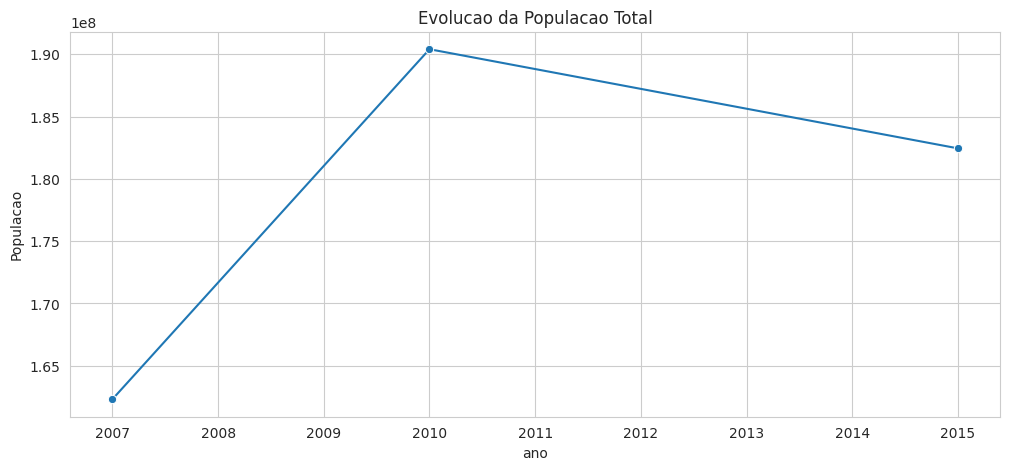

    ano  cidades    pop_total
0  2007     5277  162315134.0
1  2010     5559  190399180.0
2  2015     5277  182445338.0


In [8]:
# Salvar Parquet (Isso grava o arquivo fisico)
outfile = PROCESSED_PATH / 'populacao_completa.parquet'
df_final_demo.to_parquet(outfile, index=False)
print(f'[SUCESSO] Arquivo salvo em: {outfile}')

# Diagnóstico Visual (Grafico rapido para confirmar)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_final_demo, x='ano', y='populacao', estimator='sum', errorbar=None, marker='o')
plt.title('Evolucao da Populacao Total')
plt.ylabel('Populacao')
plt.show()

# SQL Check (Confirmar se gravou certo)
con = duckdb.connect()
print(con.execute(f"SELECT ano, COUNT(*) as cidades, SUM(populacao) as pop_total FROM '{outfile}' GROUP BY ano ORDER BY ano").df())